## Dataset: controlled affine teacher

Start with a linear teacher with no bias first:

$$
x \sim \mathcal{U}([0,1]^{d_{\text{in}}})
$$

$$
y = A x
$$

Use:

$$
d_{\text{in}}=4,
\qquad
d_{\text{out}}=2.
$$

We use this exact teacher matrix:

$$
A =
\begin{bmatrix}
1.25 & -0.75 & 0.50 & 0.20 \\
-0.40 & 0.90 & 1.10 & -0.60
\end{bmatrix}.
$$

So if

$$
x =
\begin{bmatrix}
x_1\\x_2\\x_3\\x_4
\end{bmatrix},
$$

then
$$
y_1
=
1.25x_1-0.75x_2+0.50x_3+0.20x_4,
$$
$$
y_2
=
-0.40x_1+0.90x_2+1.10x_3-0.60x_4.
$$

This matrix is good because:

* coefficients are not all positive,
* output dimensions mix input dimensions differently,
* values are moderate,
* the task is exactly solvable,
* the Hessian is analytically simple.

For the second dataset variant, add bias:
$$
y=Ax+b
$$
with
$$
b=
\begin{bmatrix}
0.35\\
-0.25
\end{bmatrix}.
$$

But I would start with $b=0$. Bias makes the Hessian slightly less clean because the bias parameters have different curvature behavior.

In [1]:
import os, sys 
# Define a little helper function that searches UP the tree until it finds a folder named "kappa" and adds it to the path. This allows us to import kappa from anywhere in the workspace without worrying about relative paths.
def recursive_dir(path):
    if 'kappa' in os.listdir(path): return path
    parent_dir = os.path.dirname(path)
    if parent_dir == path:  raise FileNotFoundError("Could not find a folder named 'kappa' in the directory tree.")
    return recursive_dir(parent_dir)
def add_kappa_to_path(): p = recursive_dir(os.getcwd()); sys.path.append(p); print(f'[INFO] Added {p} to path.')
add_kappa_to_path()
# Import kappa after adding it to the path
import kappa

[INFO] Added /Users/mbvalentin/kappa_budgeting to path.
[INFO] - κ-budgeting package imported successfully! Version: 0.1.0, URL: https://manuelblancovalentin.github.io/kappa_budgeting/


AffineDataset(
 [Input] X: 
    Shape: (1000, 4)
    Dtype: DataType.D2_FLOAT
    X <- Uniform(-1, 1)
 [Output] Y: 
    Shape: (1000, 2)
    Dtype: DataType.D2_FLOAT
    Y <- X @ A.T + b
 ---------
  A = [[ 1.25 -0.75  0.5   0.2 ]
       [-0.4   0.9   1.1  -0.6 ]]
  b = [0. 0.]
----------
Analytic Hessian:
  Lambda max: 1.0841
  Eta max: 1.8448
)


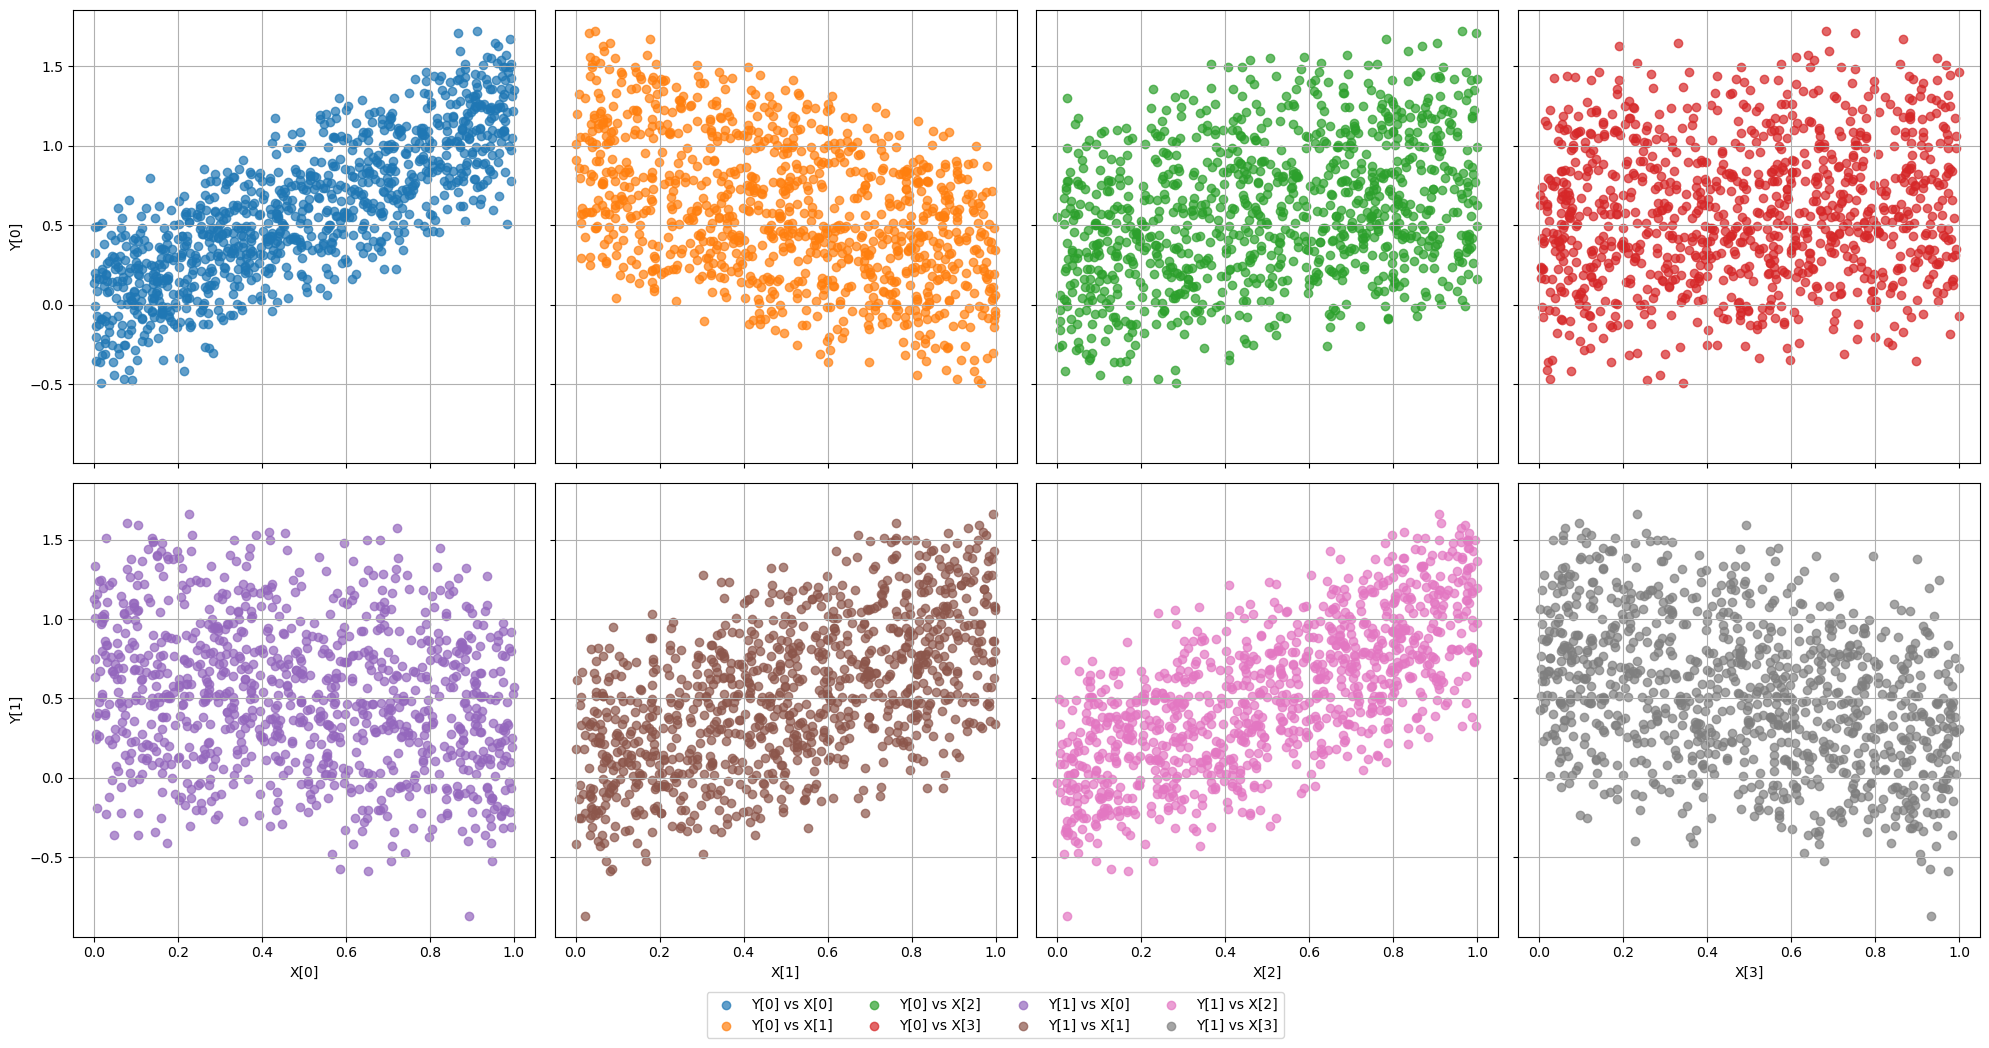

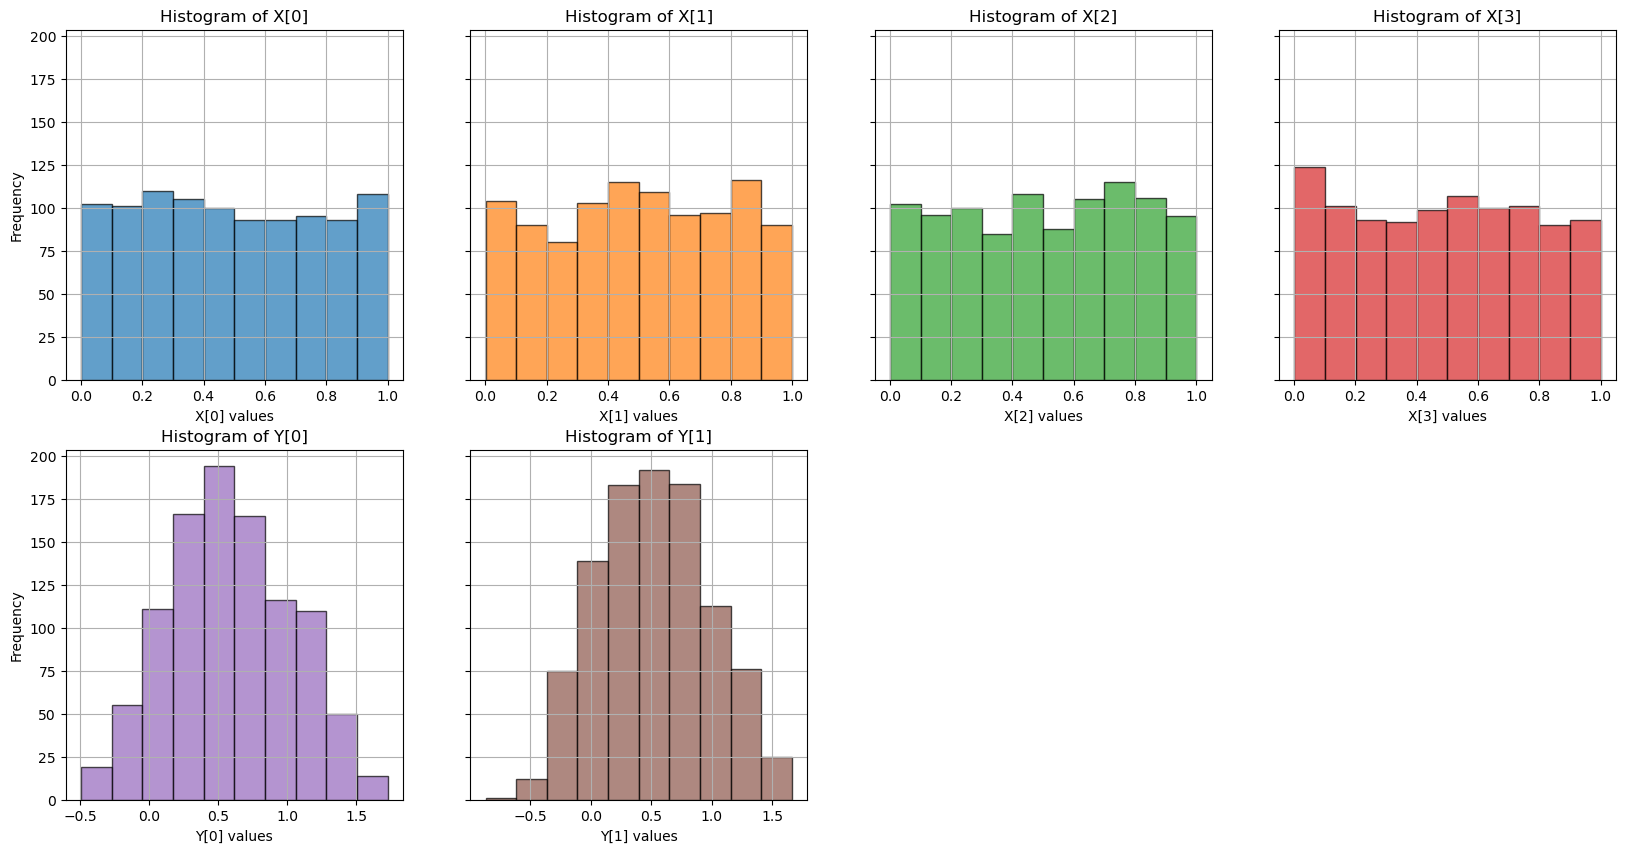

In [2]:
dataset = kappa.AffineDataset(num_samples=1000, use_bias=False)
dataset.plot()
dataset.plot_histogram()
print(dataset)

# Get the data
X, Y = dataset.get()

In [3]:
model = kappa.LinearBlockModel(dataset=dataset, num_hidden=[dataset.A.shape[0]], 
                               activation=None, use_batchnorm=False, verbose=True, 
                               use_bias=False, seed=0)
model.summary()

[INFO] - Building model with input shape (4,) and output shape (2,)
[INFO] - Added Dense layer with 2 units
[INFO] - Added final Dense layer with 2 units for output


Model: "LinearBlockModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

## BASELINE: Train model with normal dataset just to make sure it works


Training LinearBlockModel for 100 epochs with config:
  Learning rate (eta): 0.05
  Loss mode: half_mse
  Curvature EMA rho: 0.05
  Stability margin target (chi): 1.5
  Use controller: False
  Compute analytic Hessian: True
---------------------------------------------------------------
Epoch 1/100: loss=0.317341, grad=3.646e-01, C=2.078e+01, alpha_would=1.000
Epoch 2/100: loss=0.243224, grad=4.296e-01, C=3.982e+01, alpha_would=0.753
Epoch 3/100: loss=0.184566, grad=3.643e-01, C=3.889e+01, alpha_would=0.771
Epoch 4/100: loss=0.138358, grad=2.342e-01, C=1.828e+01, alpha_would=1.000
Epoch 5/100: loss=0.052039, grad=1.082e-01, C=1.943e+01, alpha_would=1.000
Epoch 6/100: loss=0.090269, grad=2.430e-01, C=3.670e+01, alpha_would=0.817
Epoch 7/100: loss=0.047134, grad=1.555e-01, C=2.891e+01, alpha_would=1.000
Epoch 8/100: loss=0.049683, grad=1.412e-01, C=1.916e+01, alpha_would=1.000
Epoch 9/100: loss=0.035585, grad=1.132e-01, C=2.767e+01, alpha_would=1.000
Epoch 10/100: loss=0.014245, grad=6.

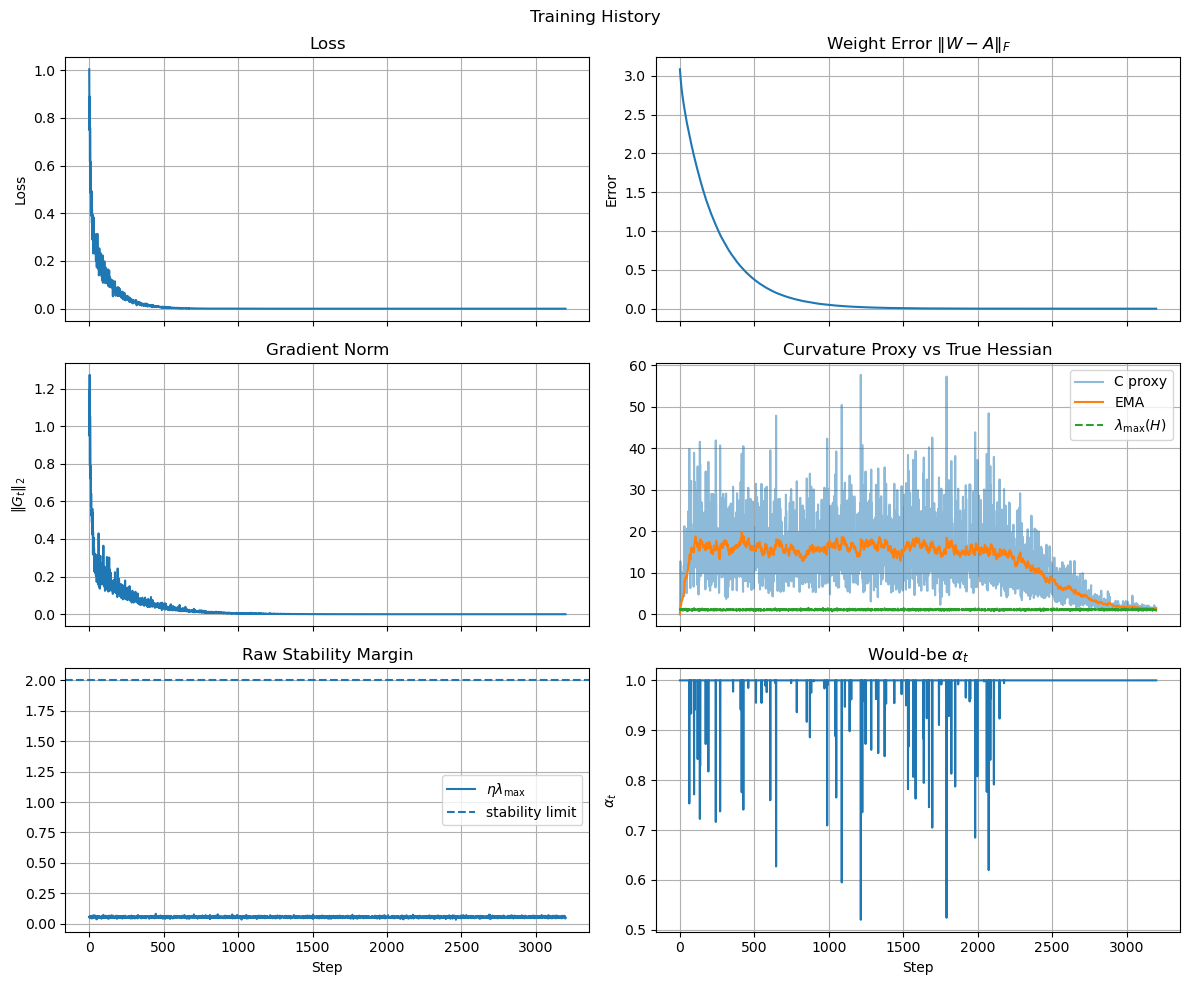

In [4]:
h = model.train_instrumented(
    X,
    Y,
    epochs=100,
    batch_size=32, #dataset.num_samples,  # Full-batch for clean Hessian metrics
    learning_rate=0.05,
    loss_mode="half_mse",
    curvature_ema_rho=0.05,
    chi=1.5,
    use_controller=False,
    compute_analytic_hessian=True,
    reference_A=dataset.reference_weight_matrix,
)
print(h)
h.plot_results(title="Training History")

## TEST1: Now reinitialize the model weights, and train first with normal dataset and later with drifted dataset (without controller). 
Expected result: the model should learn first, then with the drifted, go nuts and diverge.

[INFO] - Reinitialized kernel for layer dense with initializer GlorotUniform

Training LinearBlockModel for 20 epochs with config:
  Learning rate (eta): 0.5
  Loss mode: half_mse
  Curvature EMA rho: 0.05
  Stability margin target (chi): 1.5
  Use controller: False
  Compute analytic Hessian: True
---------------------------------------------------------------
Epoch 1/20: loss=1.005018, grad=1.217e+00, C=0.000e+00, alpha_would=1.000
Epoch 2/20: loss=0.458282, grad=5.926e-01, C=1.063e+00, alpha_would=1.000
Epoch 3/20: loss=0.323678, grad=3.333e-01, C=9.998e-01, alpha_would=1.000
Epoch 4/20: loss=0.277109, grad=2.403e-01, C=8.154e-01, alpha_would=1.000
Epoch 5/20: loss=0.250483, grad=2.092e-01, C=5.219e-01, alpha_would=1.000
Epoch 6/20: loss=0.229400, grad=1.956e-01, C=2.834e-01, alpha_would=1.000
Epoch 7/20: loss=0.210731, grad=1.865e-01, C=1.563e-01, alpha_would=1.000
Epoch 8/20: loss=0.193718, grad=1.785e-01, C=1.043e-01, alpha_would=1.000
Epoch 9/20: loss=0.178110, grad=1.711e-01, C

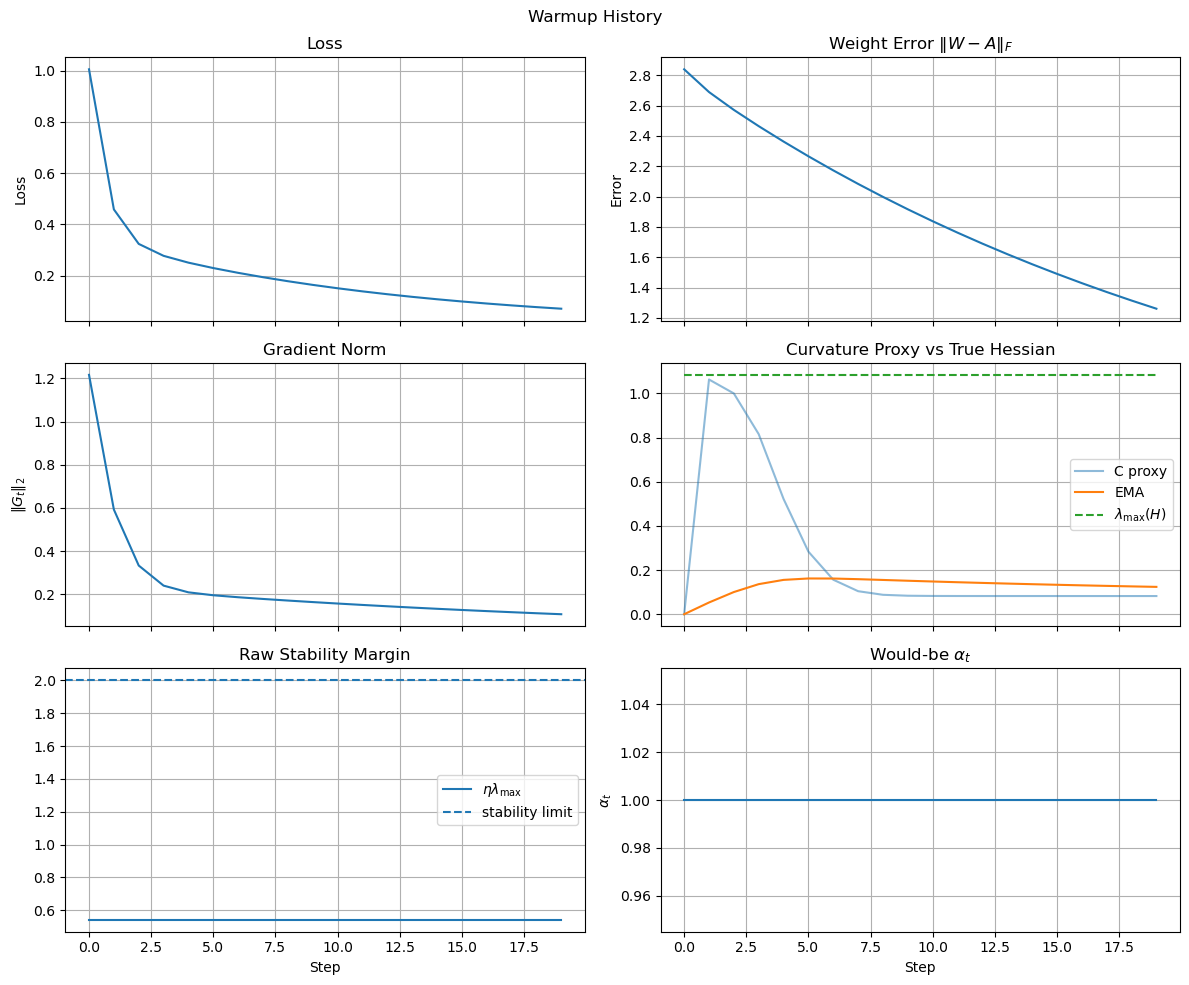

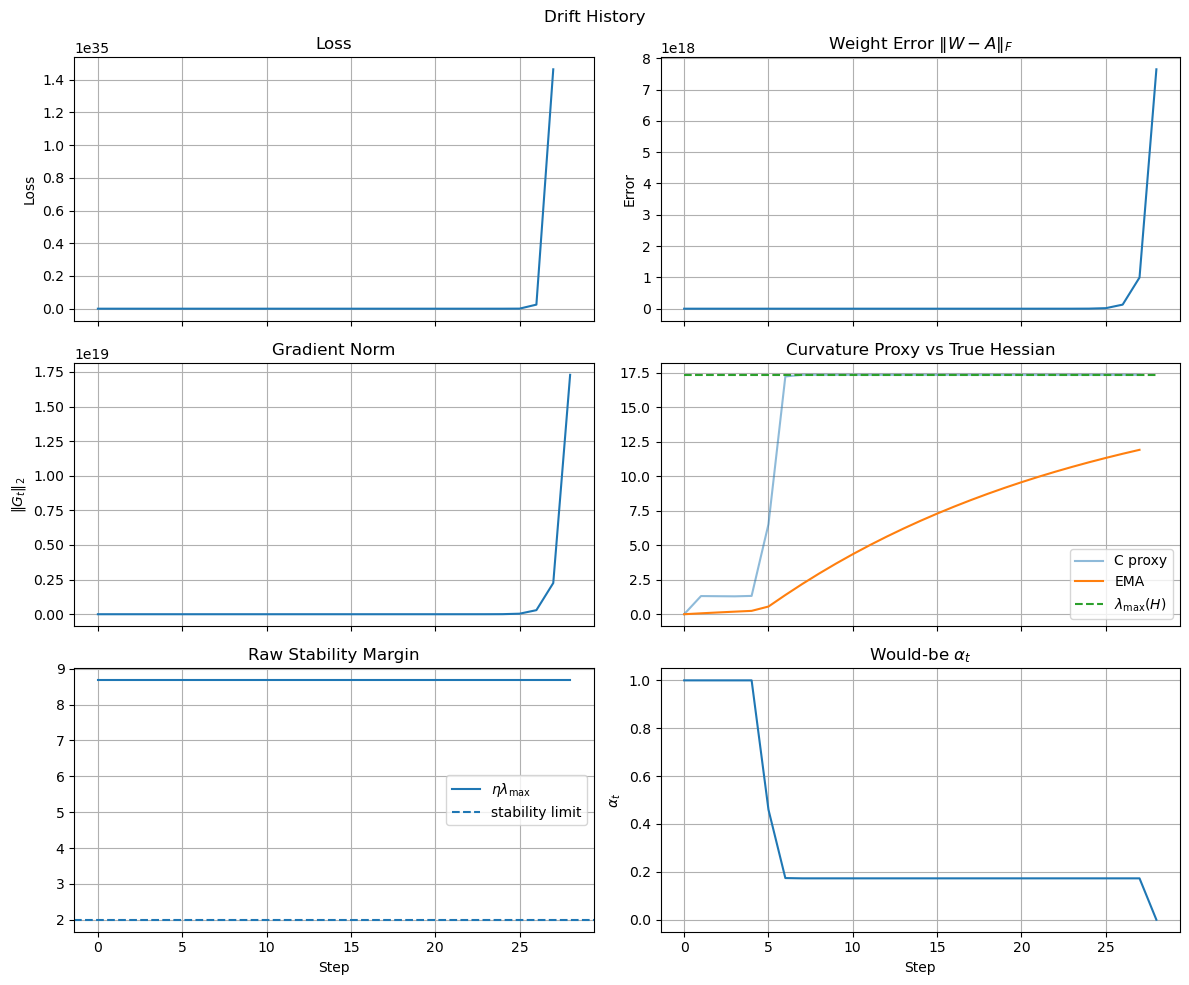

In [ ]:
# Reinit
model.reinitialize_weights()

# Phase 1: nominal warmup
h_nom = model.train_instrumented(
    X,
    Y,
    epochs=20,
    batch_size=len(X),
    learning_rate=0.5,
    use_controller=False,
    reference_A=dataset.A,
)

# Phase 2: sensor gain drift
gamma = 4.0
Xd = gamma * X
Yd = Y  # important: target remains clean

h_drift = model.train_instrumented(
    Xd,
    Yd,
    epochs=100,
    batch_size=len(Xd),
    learning_rate=0.5,
    use_controller=False,
    reference_A=dataset.A / gamma,
)

h_nom.plot_results(title="Warmup History")
h_drift.plot_results(title="Drift History")

## Test3: Same as before, but now we DO activate the controller.
Expected result: the model should learn first, then with the drifted, the controller should kick in and prevent divergence. The loss might be higher than before, but it should not diverge.

[INFO] - Reinitialized kernel for layer dense with initializer GlorotUniform

Training LinearBlockModel for 20 epochs with config:
  Learning rate (eta): 0.5
  Loss mode: half_mse
  Curvature EMA rho: 0.05
  Stability margin target (chi): 1.5
  Use controller: False
  Compute analytic Hessian: True
---------------------------------------------------------------
Epoch 1/20: loss=1.005018, grad=1.217e+00, C=0.000e+00, alpha_would=1.000
Epoch 2/20: loss=0.458282, grad=5.926e-01, C=1.063e+00, alpha_would=1.000
Epoch 3/20: loss=0.323678, grad=3.333e-01, C=9.998e-01, alpha_would=1.000
Epoch 4/20: loss=0.277109, grad=2.403e-01, C=8.154e-01, alpha_would=1.000
Epoch 5/20: loss=0.250483, grad=2.092e-01, C=5.219e-01, alpha_would=1.000
Epoch 6/20: loss=0.229400, grad=1.956e-01, C=2.834e-01, alpha_would=1.000
Epoch 7/20: loss=0.210731, grad=1.865e-01, C=1.563e-01, alpha_would=1.000
Epoch 8/20: loss=0.193718, grad=1.785e-01, C=1.043e-01, alpha_would=1.000
Epoch 9/20: loss=0.178110, grad=1.711e-01, C

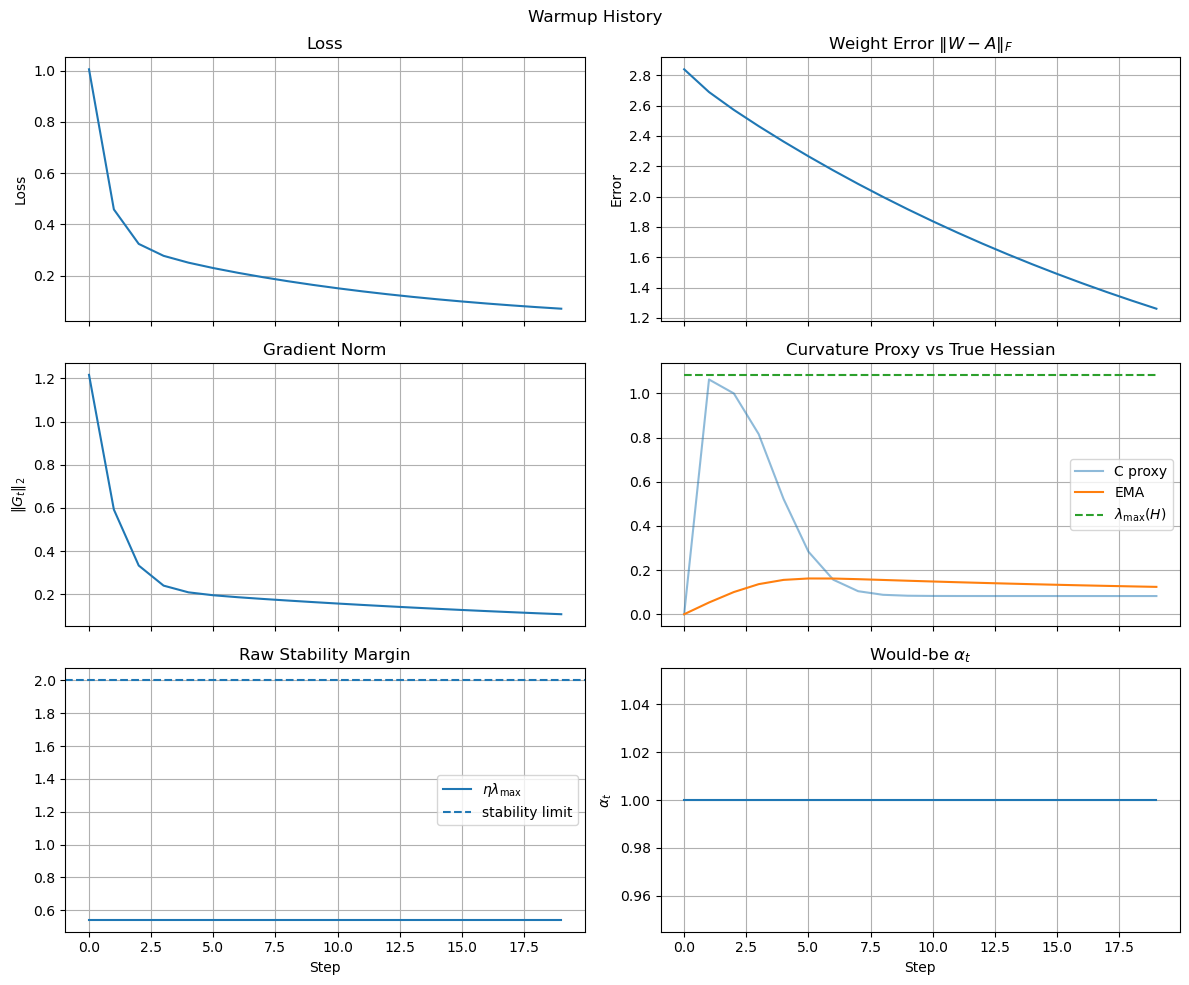

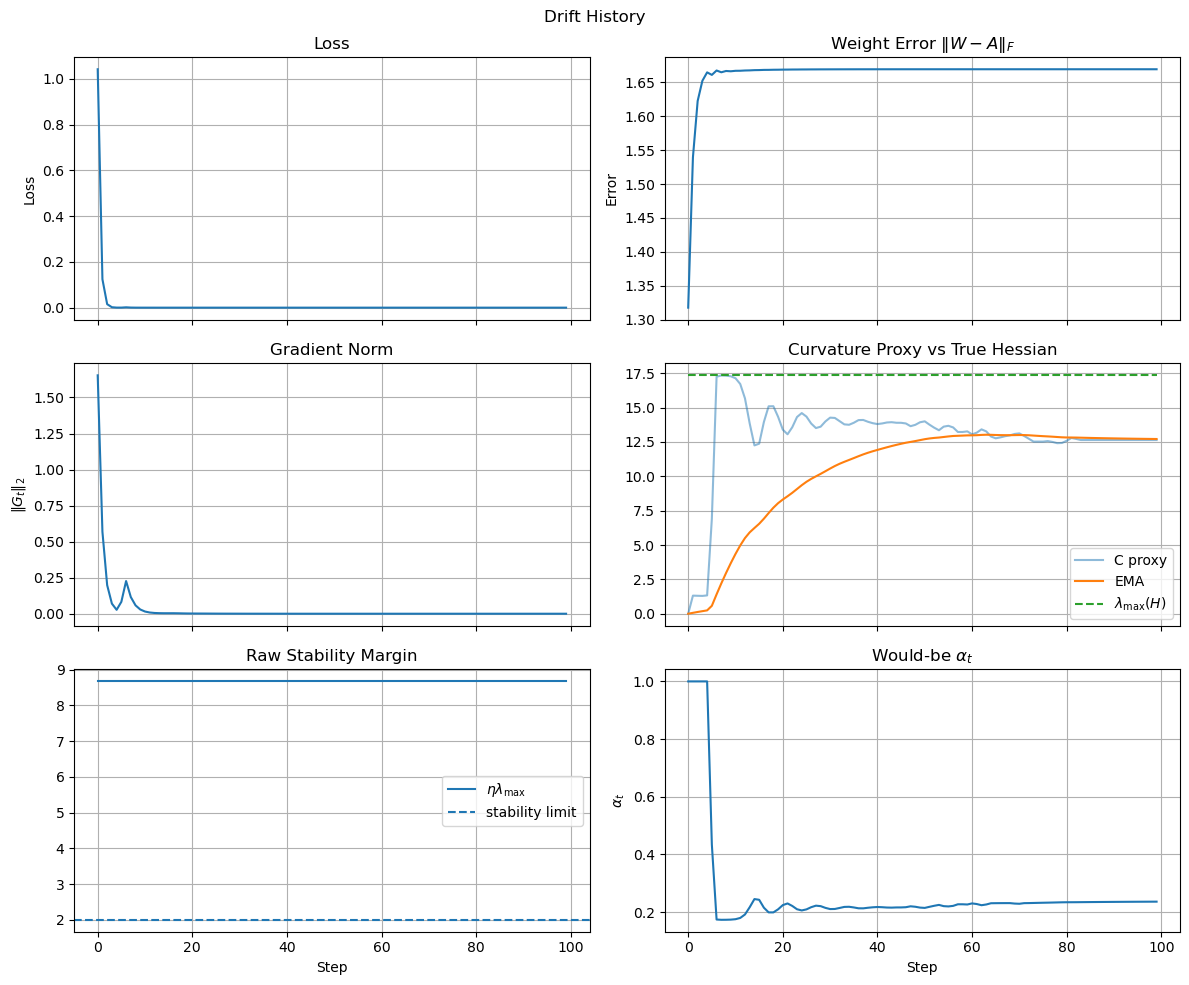

In [9]:
# Reinit
model.reinitialize_weights()

# Phase 1: nominal warmup
h_nom = model.train_instrumented(
    X,
    Y,
    epochs=20,
    batch_size=len(X),
    learning_rate=0.5,
    use_controller=False,
    reference_A=dataset.A,
)

# Phase 2: sensor gain drift
h_drift = model.train_instrumented(
    Xd,
    Yd,
    epochs=100,
    batch_size=len(Xd),
    learning_rate=0.5,
    use_controller=True,
    reference_A=dataset.A / gamma,
)

h_nom.plot_results(title="Warmup History")
h_drift.plot_results(title="Drift History")